<a href="https://colab.research.google.com/github/Harika-11/AI-ML-Tasks/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
boston = fetch_openml(name="boston", version=1, as_frame=True)

df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
linear_model = LinearRegression()

# Ensure all columns are numeric and handle potential NaNs
X_train_numeric = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

linear_model.fit(X_train_numeric, y_train)

y_pred_linear = linear_model.predict(X_test_numeric)

In [8]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

In [10]:
ridge_model = Ridge(alpha=1.0)

# Ensure all columns are numeric and handle potential NaNs for Ridge model
X_train_numeric_ridge = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_numeric_ridge = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

ridge_model.fit(X_train_numeric_ridge, y_train)

y_pred_ridge = ridge_model.predict(X_test_numeric_ridge)

In [12]:
lasso_model = Lasso(alpha=0.1)

# Ensure all columns are numeric and handle potential NaNs for Lasso model
X_train_numeric_lasso = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_numeric_lasso = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

lasso_model.fit(X_train_numeric_lasso, y_train)

y_pred_lasso = lasso_model.predict(X_test_numeric_lasso)

In [13]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, r2

In [14]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "MAE": [
        evaluate(y_test, y_pred_linear)[0],
        evaluate(y_test, y_pred_poly)[0],
        evaluate(y_test, y_pred_ridge)[0],
        evaluate(y_test, y_pred_lasso)[0]
    ],
    "MSE": [
        evaluate(y_test, y_pred_linear)[1],
        evaluate(y_test, y_pred_poly)[1],
        evaluate(y_test, y_pred_ridge)[1],
        evaluate(y_test, y_pred_lasso)[1]
    ],
    "R2 Score": [
        evaluate(y_test, y_pred_linear)[2],
        evaluate(y_test, y_pred_poly)[2],
        evaluate(y_test, y_pred_ridge)[2],
        evaluate(y_test, y_pred_lasso)[2]
    ]
})

print(results)

        Model       MAE        MSE  R2 Score
0      Linear  3.189092  24.291119  0.668759
1  Polynomial  2.574836  14.257338  0.805583
2       Ridge  3.132947  24.477191  0.666222
3       Lasso  3.145240  25.155594  0.656971


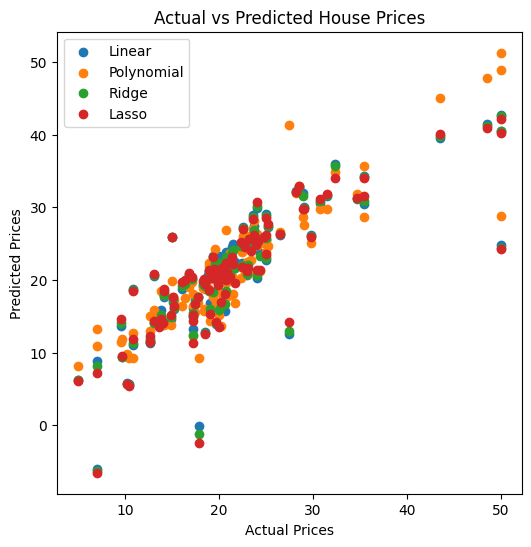

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_linear, label="Linear")
plt.scatter(y_test, y_pred_poly, label="Polynomial")
plt.scatter(y_test, y_pred_ridge, label="Ridge")
plt.scatter(y_test, y_pred_lasso, label="Lasso")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.show()

House Price Prediction Using Regression Models
Introduction

House price prediction is a common regression problem in machine learning. In this study, the Boston Housing dataset is used to train multiple regression models including Linear Regression, Polynomial Regression, Ridge Regression, and Lasso Regression. The goal is to evaluate and compare the models based on prediction accuracy and stability.

Dataset

The Boston Housing dataset contains information about housing areas in Boston. It includes features such as crime rate, number of rooms, property tax rate, and distance to employment centers. The target variable is MEDV, representing the median house value.

Methodology

The dataset was split into training and testing sets with an 80:20 ratio. Four regression models were trained:

Linear Regression

Polynomial Regression

Ridge Regression

Lasso Regression

The models were evaluated using three performance metrics:

Mean Absolute Error (MAE)

Mean Squared Error (MSE)

R² Score

Results

The results show differences in performance between the models. Linear Regression provides a baseline model. Polynomial Regression captures non-linear relationships but may increase the risk of overfitting. Ridge Regression helps reduce overfitting by applying L2 regularization, while Lasso Regression performs feature selection through L1 regularization.

Model Stability

Ridge and Lasso models improve stability by penalizing large coefficients. Ridge regression reduces coefficient variance, while Lasso regression can shrink some coefficients to zero, effectively selecting important features.

Visualization

A scatter plot comparing actual vs predicted values was used to visually evaluate model performance. A good model should have points close to the diagonal line.

Conclusion

Among the models, regularized methods such as Ridge and Lasso generally provide more stable predictions compared to simple Linear Regression. Polynomial Regression can improve accuracy but must be carefully tuned to avoid overfitting. Overall, regularization techniques improve model robustness and generalization.